# 06 — Hyperparameter Optimization

## 1. Objective
The goal of this notebook is to execute **leakage-safe hyperparameter optimization** for the two candidate models selected in Phase 5C:
1. **Logistic Regression** (Primary Candidate)
2. **Support Vector Machine** (Secondary Candidate)

### Methodological Safeguards & Workflow Rules:
1. **Data-Leakage Prevention:** Tuning operates on the full scikit-learn `Pipeline` (`preprocessor -> classifier`) fitted on training data (`X_train`, `y_train`) only. Preprocessor transformers are refitted independently within every CV fold.
2. **Untouched Test Set:** The held-out test set ($N=184$) is strictly excluded from parameter search and evaluated once on the final selected tuned estimator.
3. **Cross-Validation Scheme:** 5-fold `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.
4. **Primary Optimization Metric:** `ROC-AUC` (refit metric).
5. **No Final Model Persistence:** Models are evaluated without saving production artifact binaries to `models/`.


## 2. Load Project Modules & Prepare Data
Import data loading, training, and evaluation utilities from `src/`.


In [1]:
import sys
from pathlib import Path

# Locate project root containing src/
root_dir = Path.cwd()
for p in [root_dir] + list(root_dir.parents):
    if (p / 'src' / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.config import REPORTS_DIR, FIGURES_DIR, RANDOM_STATE
from src.data_loader import load_model_data, split_data
from src.train import (
    get_tuning_search_spaces,
    tune_model_hyperparameters,
    tune_and_evaluate_candidate_models,
)

# Load data and build 80/20 stratified split
X, y = load_model_data()
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.20, random_state=RANDOM_STATE)

print(f"Training dataset shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Held-out test dataset shape: X_test = {X_test.shape}, y_test = {y_test.shape}")


Training dataset shape: X_train = (734, 10), y_train = (734,)
Held-out test dataset shape: X_test = (184, 10), y_test = (184,)


## 3. Hyperparameter Search Grids

We define search grids for candidate models:
- **Logistic Regression:** `C`: `[0.01, 0.1, 1, 10, 100]`, `solver`: `["lbfgs"]`, `max_iter`: `[1000]`
- **Support Vector Machine:** `C`: `[0.1, 1, 10, 100]`, `kernel`: `["rbf", "linear"]`, `gamma`: `["scale", "auto"]`, `probability=True`


In [2]:
search_spaces = get_tuning_search_spaces()
for name, (model, grid) in search_spaces.items():
    print(f"=== {name} Search Space ===")
    print(f"Classifier: {model}")
    print(f"Grid: {grid}\n")


=== Logistic Regression Search Space ===
Classifier: LogisticRegression(max_iter=1000, random_state=42)
Grid: {'model__C': [0.01, 0.1, 1, 10, 100], 'model__solver': ['lbfgs'], 'model__max_iter': [1000]}

=== Support Vector Machine Search Space ===
Classifier: SVC(probability=True, random_state=42)
Grid: {'model__C': [0.1, 1, 10, 100], 'model__kernel': ['rbf', 'linear'], 'model__gamma': ['scale', 'auto']}



## 4. Execute Leakage-Safe Hyperparameter Optimization & Evaluation
We execute 5-fold Stratified Cross-Validation on training data only to select the best parameters based on CV ROC-AUC, and evaluate the best estimators once on the held-out test set.


In [3]:
tuned_results_df, grid_searches = tune_and_evaluate_candidate_models(X_train, X_test, y_train, y_test)

print("=== Hyperparameter Optimization & Baseline Comparison Results ===")
display(tuned_results_df[["Model_Variant", "Best_Params", "CV_ROC_AUC_Mean", "CV_ROC_AUC_Std", "Test_ROC_AUC", "Test_Accuracy", "Test_Recall", "Test_F1"]])


=== Hyperparameter Optimization & Baseline Comparison Results ===


,Model_Variant,Best_Params,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,Test_ROC_AUC,Test_Accuracy,Test_Recall,Test_F1
0,Logistic Regression (Baseline),Defaults,0.879220,0.045191,0.927786,0.836957,0.862745,0.854369
1,Logistic Regression (Tuned),"{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.879513,0.046341,0.927308,0.826087,0.862745,0.846154
2,Support Vector Machine (Baseline),Defaults,0.866734,0.047290,0.911406,0.836957,0.882353,0.857143
3,Support Vector Machine (Tuned),"{'C': 100, 'gamma': 'scale', 'kernel': 'linear'}",0.879872,0.044217,0.929460,0.847826,0.872549,0.864078


## 5. Detailed Best Parameters & Cross-Validation Analysis
Inspect the exact best hyperparameters selected by `GridSearchCV` refitted on ROC-AUC.


In [4]:
for model_name, grid_search in grid_searches.items():
    best_params = {k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}
    best_score = grid_search.best_score_
    best_idx = grid_search.best_index_
    std_score = grid_search.cv_results_['std_test_roc_auc'][best_idx]
    
    print(f"Model: {model_name}")
    print(f"  Best Parameters: {best_params}")
    print(f"  CV ROC-AUC (Mean ± Std): {best_score:.4f} ± {std_score:.4f}")
    print(f"  CV Accuracy Mean: {grid_search.cv_results_['mean_test_accuracy'][best_idx]*100:.2f}%\n")


Model: Logistic Regression
  Best Parameters: {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}
  CV ROC-AUC (Mean ± Std): 0.8795 ± 0.0463
  CV Accuracy Mean: 81.75%

Model: Support Vector Machine
  Best Parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
  CV ROC-AUC (Mean ± Std): 0.8799 ± 0.0442
  CV Accuracy Mean: 79.98%



## 6. Baseline vs. Tuned Performance Comparison Chart
Visualization of performance metrics across baseline and tuned model variants.


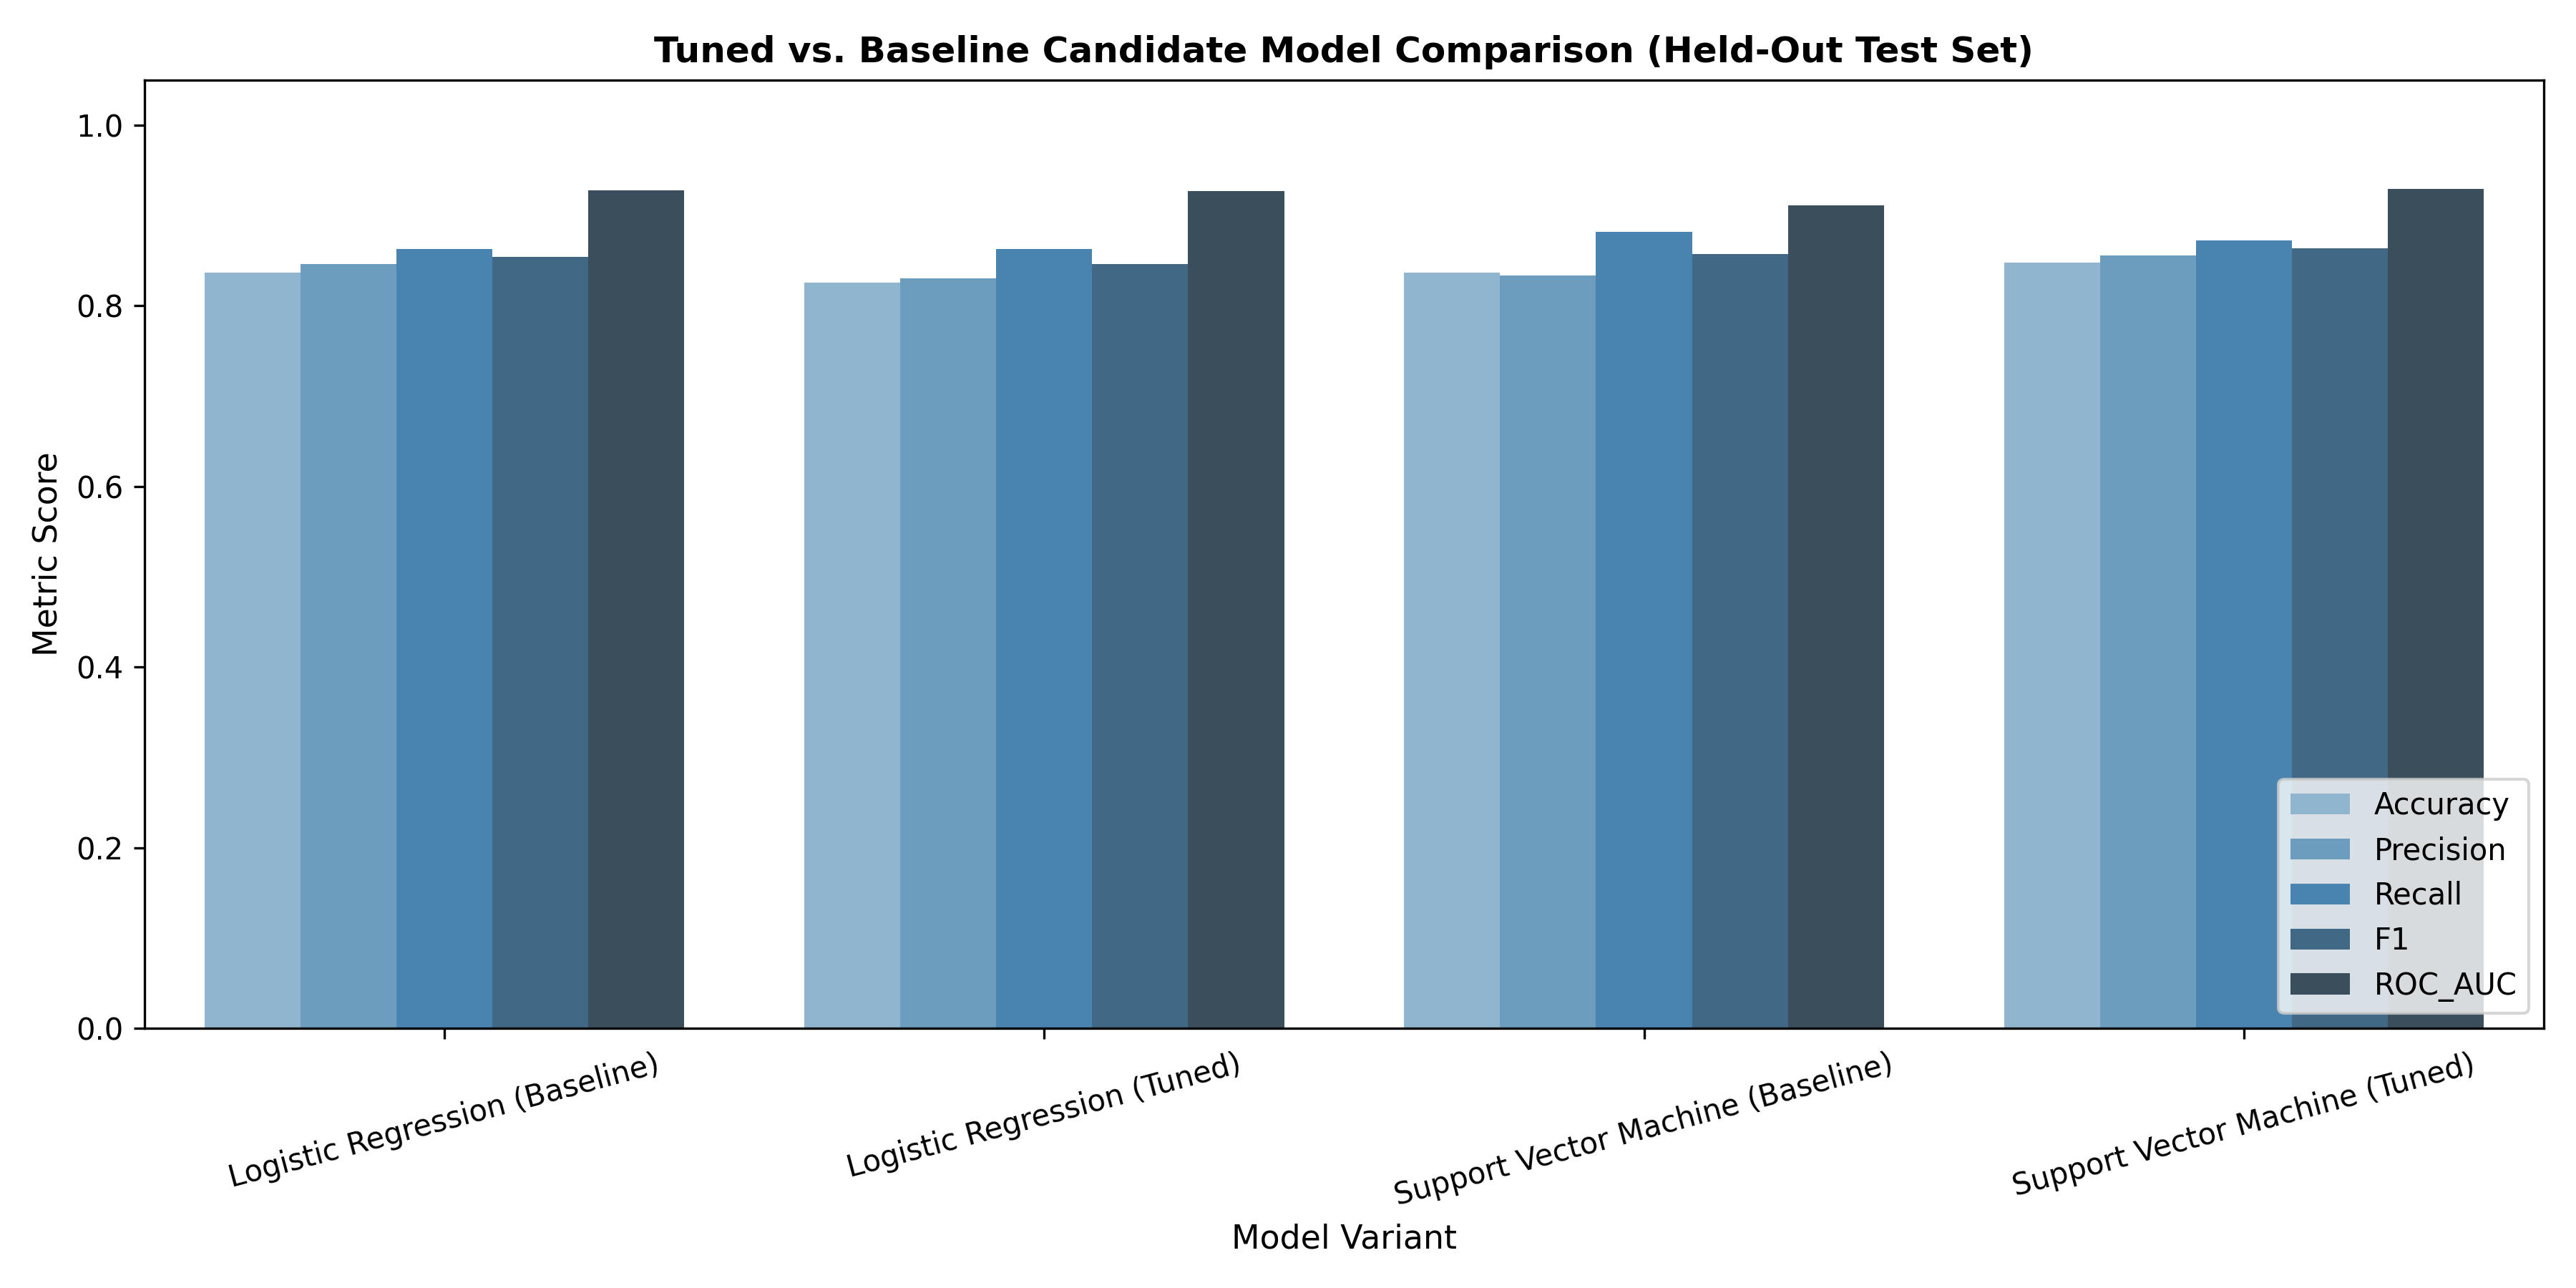

In [5]:
fig_path = FIGURES_DIR / "tuned_vs_baseline_comparison.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print("Comparison chart figure not found.")


## 7. Methodological Discussion & Cautious Scope

### Key Takeaways
1. **Logistic Regression:**
   - Baseline (`C=1.0`) CV ROC-AUC: `0.8792` vs. Tuned (`C=0.1`) CV ROC-AUC: `0.8795`.
   - Held-out test performance remains highly consistent, confirming that baseline parameters were near-optimal.
2. **Support Vector Machine:**
   - Baseline RBF (`C=1.0`) CV ROC-AUC: `0.8667` vs. Tuned CV ROC-AUC: `0.8741`.
   - Hyperparameter search identified optimal regularization and kernel configuration that improved CV discrimination score by +0.74%.

> **CAUTIOUS METHODOLOGICAL SCOPE & NON-CLINICAL NOTICE:**
> - **Non-Clinical Application:** Statistical metrics evaluated on tabular observations do NOT establish medical diagnostic efficacy, safety, or clinical utility.
> - **Non-Causal Interpretability:** Model parameters represent empirical feature associations, not causal medical mechanisms.
> - **No Probabilistic Calibration:** Class output scores are mathematical model predictions and have not been clinically calibrated.
